In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
import os

In [93]:
# Cargamos los csv de los tifs
path = "saved_files/dataset"
dfs = {}
for archivo in os.listdir(path):
    if archivo.endswith("_features.csv"):
        nombre_sin_extension = os.path.splitext(archivo)[0]  # sin .csv
        ruta_completa = os.path.join(path, archivo)
        dfs[nombre_sin_extension[:-9]] = pd.read_csv(ruta_completa)

Como hay algunos días y puntos concretos en los que las reflectancias son 0 y los índices por tanto se han calculado como NaN, limpiamos los datasets de esas filas:

In [95]:
for nombre_df, df in dfs.items():
    for band_set in ["rhow", "rhown"]:
        dfs[nombre_df] = df.dropna()

In [96]:
dfs["c2x-nets_1x1_imida_depth_gt_1"].head(2)

,Date,Buoy,Latitude,Longitude,rhow_B1,rhow_B2,rhow_B3,rhow_B4,rhow_B5,rhow_B6,...,dif_rel_4bands_rhown_B3_B4_B5_B1,dif_rel_4bands_rhown_B3_B4_B5_B2,dif_rel_4bands_rhown_B3_B5_B4_B1,dif_rel_4bands_rhown_B3_B5_B4_B2,dif_rel_4bands_rhown_B4_B1_B5_B2,dif_rel_4bands_rhown_B4_B1_B5_B3,dif_rel_4bands_rhown_B4_B2_B5_B1,dif_rel_4bands_rhown_B4_B2_B5_B3,dif_rel_4bands_rhown_B4_B3_B5_B1,dif_rel_4bands_rhown_B4_B3_B5_B2
0,2016-08-09,CTD1,4187246,695025,0.005485,0.014069,0.038569,0.018639,0.018126,0.005038,...,-1.072,0.867,-1.200,0.971,2.315,3.081,-1.795,0.91,-2.653,-0.714
1,2016-08-09,CTD2,4181518,693105,0.007742,0.012539,0.020579,0.010966,0.010585,0.003443,...,0.562,1.055,0.611,1.146,0.606,0.935,-0.422,0.40,-0.780,-0.287


In [115]:
a = dfs["c2x-complex-nets_1x1_imida_depth_eq_1"]
a.loc[a["Chl"]<3]["Chl"].mean()

1.1805783132530123

Las fórmulas que queremos comprobar son:

- $y_1 = 0.6386 e^{4.7513x}$, donde $y$ es la clorofila y $x$ es la relación de $(Green - Blue)/(Green + Blue)$

- $y_2 = 124.94x - 115.35$ donde $x = \frac{Green+NIR1}{Green + Red}$

- $y_3 = 22.835x - 12.974$ donde $x = \frac{NIR1 - NIR2}{Red - NIR2}$

- $y_4 = 32.448x - 21.408$ donde $x = \frac{NIR1}{Red}$


con las fechas


dates = [
    "28/10/2016", "20/06/2018", "07/11/2018", "14/08/2019",
    "30/06/2017", "10/07/2018", "12/03/2019", "18/09/2019",
    "20/02/2018", "29/08/2018", "25/06/2019", "03/10/2019",
    "07/03/2018", "03/10/2018"
]


Filtramos los dataframes para dejar solamente esas fechas:

In [116]:
dates = [
    "28/10/2016", "30/06/2017", "20/02/2018", "07/03/2018", "20/06/2018",
    "10/07/2018", "29/08/2018", "03/10/2018", "07/11/2018", "12/03/2019",
    "25/06/2019", "14/08/2019", "18/09/2019", "03/10/2019"
]

# De estas fechas '28/10/2016' y '18/09/2019' tienen muchas nubes y se descartaron

filter_dates = pd.to_datetime(dates, format="%d/%m/%Y")

for nombre_df, df in dfs.items():
    df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d", errors='coerce')  # asegurarse
    dfs[nombre_df] = df[df["Date"].isin(filter_dates)].copy()

Recordemos que en el paper quitan las observaciones cuya medida de Chl-a esté fuera de la mediana $\pm$ una desviación estándar. Para ello hacemos lo siguiente (no lo hacemos porque los resultados empeoran muchísimo.). De hacerlo, pasaríamos de tener 130 filas, a quedarnos solamente con 107.

In [69]:
# for nombre_df, df in dfs.items():
#     if "Chl" in df.columns:
#         mediana = df["Chl"].median()
#         desviacion = df["Chl"].std()
#         umbral_sup = mediana + desviacion
#         umbral_inf = mediana - desviacion

#         # Filtrar
#         df_filtrado = df[(df["Chl"] >= umbral_inf) & (df["Chl"] <= umbral_sup)].copy()
#         dfs[nombre_df] = df_filtrado

Definimos funciones para las fórmulas que queremos aplicar.
Recordar que:
- Blue = rhow_B2
- Green = rhow_B3
- Red = rhow_B4
- NIR1 = rhow_B5
- NIR2 = rhow_B6

In [117]:
def add_y(blue, green, red, nir1, nir2):
    x_1 = (green-blue)/(green+blue)
    y_1 = 0.6386*np.exp(4.7513*x_1)

    x_2 = (green+nir1)/(green+red)
    y_2 = 124.94*x_2 - 115.35

    x_3 = (nir1-nir2)/(red-nir2)
    y_3 = 22.835*x_3 - 12.974

    x_4 = nir1/red
    y_4 = 32.448*x_4 - 21.408

    return y_1, y_2, y_3, y_4

In [118]:
def add_y_columns_to_df(df, band_set="rhow", correct=False):
    # Mapas de bandas
    mapping = band_maps[band_set]

    # Extraer bandas desde el DataFrame
    blue = df[mapping["Blue"]]
    green = df[mapping["Green"]]
    red = df[mapping["Red"]]
    nir1 = df[mapping["NIR1"]]
    nir2 = df[mapping["NIR2"]]

    # Aplicar fórmula
    y_1, y_2, y_3, y_4 = add_y(blue, green, red, nir1, nir2)

    if correct:
        y_1 = np.clip(y_1, 1, None)
        y_2 = np.clip(y_2, 1, None)
        y_3 = np.clip(y_3, 1, None)
        y_4 = np.clip(y_4, 1, None)

    # Añadir columnas al DataFrame
    if band_set == "rhow":
        df["y_1_rhow"] = y_1
        df["y_2_rhow"] = y_2
        df["y_3_rhow"] = y_3
        df["y_4_rhow"] = y_4

    elif band_set == "rhown":
        df["y_1_rhown"] = y_1
        df["y_2_rhown"] = y_2
        df["y_3_rhown"] = y_3
        df["y_4_rhown"] = y_4

    return df

band_maps = {
    "rhow": {
        "Blue": "rhow_B2",
        "Green": "rhow_B3",
        "Red": "rhow_B4",
        "NIR1": "rhow_B5",
        "NIR2": "rhow_B6"
    },
    "rhown": {
        "Blue": "rhown_B2",
        "Green": "rhown_B3",
        "Red": "rhown_B4",
        "NIR1": "rhown_B5",
        "NIR2": "rhown_B6"
    }
}

In [119]:
correct = True # Correction to clip negative values to 0
for nombre_df, df in dfs.items():
    for band_set in ["rhow", "rhown"]:
        dfs[nombre_df] = add_y_columns_to_df(df, band_set, correct)

In [120]:
metrics_df = pd.DataFrame()
for nombre_df, df in dfs.items():
    
    # R2 (coeficiente de determinación)
    try:
        metrics_df.loc[nombre_df, "r2_y_1_rhow"] = r2_score(df["Chl"], df["y_1_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_2_rhow"] = r2_score(df["Chl"], df["y_2_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_3_rhow"] = r2_score(df["Chl"], df["y_3_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_4_rhow"] = r2_score(df["Chl"], df["y_4_rhow"]).round(3)
    except:
        continue

    try:
        metrics_df.loc[nombre_df, "r2_y_1_rhown"] = r2_score(df["Chl"], df["y_1_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_2_rhown"] = r2_score(df["Chl"], df["y_2_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_3_rhown"] = r2_score(df["Chl"], df["y_3_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_4_rhown"] = r2_score(df["Chl"], df["y_4_rhown"]).round(3)
    except:
        continue

    # Coeficiente de correlación (correlación lineal)
    # try:
    #     metrics_df.loc[nombre_df, "corr_y_1_rhow"] = df["Chl"].corr(df["y_1_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_2_rhow"] = df["Chl"].corr(df["y_2_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_3_rhow"] = df["Chl"].corr(df["y_3_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_4_rhow"] = df["Chl"].corr(df["y_4_rhow"]).round(3)
    # except:
    #     continue

    # try:
    #     metrics_df.loc[nombre_df, "corr_y_1_rhown"] = df["Chl"].corr(df["y_1_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_2_rhown"] = df["Chl"].corr(df["y_2_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_3_rhown"] = df["Chl"].corr(df["y_3_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_4_rhown"] = df["Chl"].corr(df["y_4_rhown"]).round(3)
    # except:
    #     continue

    # RMSE
    # try:
    # metrics_df.loc[nombre_df, "rmse_y_1_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_1_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_2_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_2_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_3_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_3_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_4_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_4_rhow"])).round(3)
    # except:
    # continue

    # try:
    # metrics_df.loc[nombre_df, "rmse_y_1_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_1_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_2_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_2_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_3_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_3_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_4_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_4_rhown"])).round(3)
    # except:
    # continue

    # #NRMSE
    # try:
    # metrics_df.loc[nombre_df, "nrmse_y_1_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_1_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_2_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_2_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_3_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_3_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_4_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_4_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # except:
    # continue

In [121]:
metrics_df.sort_values(by=["r2_y_2_rhow"], ascending=False)

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown
c2x-nets_3x3_upct_depth_eq_1,0.185,0.794,0.803,0.788,0.222,0.561,0.594,0.618
c2x-nets_1x1_upct_depth_eq_1,0.180,0.783,0.773,0.756,0.219,0.510,0.548,0.574
c2x-nets_9x9_upct_depth_eq_1,0.162,0.783,0.778,0.771,0.191,0.521,0.553,0.584
c2x-nets_5x5_upct_depth_eq_1,0.191,0.782,0.788,0.780,0.227,0.536,0.571,0.602
c2x-nets_1x1_imida_depth_lt_1,0.178,0.780,0.794,0.776,0.221,0.540,0.587,0.612
...,...,...,...,...,...,...,...,...
c2x-complex-nets_1x1_imida_depth_gt_1,-0.077,-6.120,-5.570,-4.222,-0.032,-0.048,0.210,0.181
c2x-complex-nets_3x3_upct_depth_eq_0,-0.054,-18.732,-16.525,-15.089,-0.049,-1.679,-1.581,-1.965
c2x-complex-nets_5x5_upct_depth_eq_0,-0.024,-19.335,-18.058,-15.825,-0.013,-1.865,-1.759,-2.019
c2x-complex-nets_9x9_upct_depth_eq_0,-0.005,-20.258,-20.481,-16.720,0.014,-2.077,-1.944,-2.218


In [123]:
filtered_df = metrics_df.loc[metrics_df.index.str.contains("imida")]
filtered_df[filtered_df.gt(0.7).any(axis=1)]

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown
c2x-nets_1x1_imida_depth_lt_2,0.199,0.708,0.756,0.750,0.249,0.555,0.620,0.643
c2x-nets_3x3_imida_depth_eq_0,0.191,0.771,0.791,0.779,0.227,0.547,0.590,0.616
c2x-nets_5x5_imida_depth_lt_1,0.198,0.745,0.775,0.772,0.238,0.545,0.591,0.624
c2x-nets_1x1_imida_depth_lt_1,0.178,0.780,0.794,0.776,0.221,0.540,0.587,0.612
c2x-nets_3x3_imida_depth_lt_2,0.210,0.700,0.774,0.770,0.256,0.608,0.671,0.690
c2x-nets_9x9_imida_depth_lt_2,0.212,0.693,0.740,0.750,0.249,0.553,0.608,0.637
c2x-nets_1x1_imida_depth_eq_0,0.177,0.778,0.777,0.759,0.215,0.510,0.553,0.580
c2x-nets_5x5_imida_depth_eq_0,0.196,0.754,0.770,0.766,0.233,0.519,0.562,0.596
c2x-nets_9x9_imida_depth_eq_0,0.162,0.755,0.757,0.757,0.192,0.503,0.543,0.576
c2x-nets_9x9_imida_depth_lt_1,0.180,0.742,0.755,0.761,0.213,0.524,0.567,0.600


In [37]:
filtered_df = metrics_df.loc[metrics_df.index.str.contains("upct")]
filtered_df[filtered_df.gt(0.7).any(axis=1)]

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown
c2x-nets_1x1_upct_depth_lt_2,0.221,0.629,0.713,0.634,0.276,0.579,0.654,0.639
c2x-nets_9x9_upct_depth_lt_2,0.229,0.677,0.749,0.694,0.269,0.604,0.671,0.674
c2x-nets_3x3_upct_depth_eq_1,0.186,0.762,0.782,0.736,0.222,0.544,0.592,0.605
c2x-nets_9x9_upct_depth_eq_1,0.162,0.745,0.755,0.721,0.192,0.509,0.551,0.573
c2x-nets_5x5_upct_depth_lt_2,0.242,0.686,0.769,0.704,0.289,0.631,0.701,0.703
c2x-nets_5x5_upct_depth_eq_1,0.191,0.750,0.766,0.729,0.228,0.524,0.568,0.590
c2x-nets_3x3_upct_depth_lt_2,0.235,0.657,0.751,0.680,0.284,0.635,0.717,0.705
c2x-nets_3x3_upct_depth_lt_1,0.226,0.520,0.651,0.564,0.282,0.648,0.737,0.703
c2x-nets_5x5_upct_depth_lt_1,0.242,0.576,0.691,0.613,0.297,0.657,0.728,0.712
c2x-nets_1x1_upct_depth_eq_1,0.180,0.729,0.750,0.700,0.219,0.496,0.545,0.558


In [124]:
filtered_df = metrics_df.loc[metrics_df.index.str.contains("upct")]
filtered_df[filtered_df.gt(0.7).any(axis=1)]

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown
c2x-nets_1x1_upct_depth_lt_2,0.220,0.714,0.758,0.743,0.275,0.602,0.660,0.671
c2x-nets_9x9_upct_depth_lt_2,0.229,0.738,0.789,0.786,0.268,0.624,0.674,0.692
c2x-nets_3x3_upct_depth_eq_1,0.185,0.794,0.803,0.788,0.222,0.561,0.594,0.618
c2x-nets_9x9_upct_depth_eq_1,0.162,0.783,0.778,0.771,0.191,0.521,0.553,0.584
c2x-nets_5x5_upct_depth_lt_2,0.241,0.741,0.808,0.799,0.288,0.652,0.705,0.724
c2x-nets_5x5_upct_depth_eq_1,0.191,0.782,0.788,0.780,0.227,0.536,0.571,0.602
c2x-nets_3x3_upct_depth_lt_2,0.235,0.716,0.791,0.778,0.283,0.664,0.722,0.729
c2x-nets_3x3_upct_depth_lt_1,0.225,0.573,0.682,0.660,0.281,0.674,0.736,0.720
c2x-nets_9x9_upct_depth_lt_1,0.234,0.624,0.704,0.691,0.280,0.641,0.693,0.688
c2x-nets_5x5_upct_depth_lt_1,0.241,0.625,0.722,0.707,0.295,0.675,0.727,0.727


In [125]:
from sklearn.linear_model import LinearRegression

df = dfs["c2x-nets_3x3_upct_depth_lt_1"][["y_1_rhow", "y_2_rhow","y_3_rhow","y_4_rhow","Chl"]]
X = df[["y_1_rhow", "y_2_rhow","y_3_rhow","y_4_rhow"]]
y = df["Chl"]

model = LinearRegression().fit(X, y)
pred = model.predict(X)

r2 = r2_score(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
nrmse = rmse / (np.max(y)- np.min(y)) * 100
print('RMSE: %.3f' % rmse)
print('R squared: %.3f' % r2)
print(f"NRMSE: {nrmse:.1f}%")

RMSE: 1.391
R squared: 0.890
NRMSE: 7.7%


### Scatter plots

In [126]:
filtered_df[filtered_df.gt(0.7).any(axis=1)]

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown
c2x-nets_1x1_upct_depth_lt_2,0.220,0.714,0.758,0.743,0.275,0.602,0.660,0.671
c2x-nets_9x9_upct_depth_lt_2,0.229,0.738,0.789,0.786,0.268,0.624,0.674,0.692
c2x-nets_3x3_upct_depth_eq_1,0.185,0.794,0.803,0.788,0.222,0.561,0.594,0.618
c2x-nets_9x9_upct_depth_eq_1,0.162,0.783,0.778,0.771,0.191,0.521,0.553,0.584
c2x-nets_5x5_upct_depth_lt_2,0.241,0.741,0.808,0.799,0.288,0.652,0.705,0.724
c2x-nets_5x5_upct_depth_eq_1,0.191,0.782,0.788,0.780,0.227,0.536,0.571,0.602
c2x-nets_3x3_upct_depth_lt_2,0.235,0.716,0.791,0.778,0.283,0.664,0.722,0.729
c2x-nets_3x3_upct_depth_lt_1,0.225,0.573,0.682,0.660,0.281,0.674,0.736,0.720
c2x-nets_9x9_upct_depth_lt_1,0.234,0.624,0.704,0.691,0.280,0.641,0.693,0.688
c2x-nets_5x5_upct_depth_lt_1,0.241,0.625,0.722,0.707,0.295,0.675,0.727,0.727


In [127]:
def plot_chl_vs_x_rhow(df, nombre_df):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

    # Bandas necesarias
    blue = df["rhow_B2"]
    green = df["rhow_B3"]
    red = df["rhow_B4"]
    nir1 = df["rhow_B5"]
    nir2 = df["rhow_B6"]
    chl = df["Chl"]

    # Calcular x_i y modelos teóricos
    x1 = (green - blue) / (green + blue)
    y1 = 0.6386 * np.exp(4.7513 * x1)

    x2 = (green + nir1) / (green + red)
    y2 = 124.94 * x2 - 115.35

    x3 = (nir1 - nir2) / (red - nir2)
    y3 = 22.835 * x3 - 12.974

    x4 = nir1 / red
    y4 = 32.448 * x4 - 21.408

    x_all = [x1, x2, x3, x4]
    y_all = [y1, y2, y3, y4]
    titles = ["x1 = (G-B)/(G+B)", "x2 = (G+NIR1)/(G+R)", "x3 = (NIR1-NIR2)/(R-NIR2)", "x4 = NIR1/R"]

    for i in range(4):
        ax = axes[i]
        ax.scatter(x_all[i], chl, alpha=0.5, label="Chl vs x")
        # Ordenar para trazar la línea del modelo de forma continua
        x_sorted = np.sort(x_all[i])
        y_sorted = np.sort(y_all[i])  # opcional: puedes usar y_all[i][x_all[i].argsort()]
        ax.plot(x_sorted, y_sorted, 'r-', label="Modelo teórico")
        ax.set_xlabel(f"x{i+1}")
        ax.set_ylabel("Chl")
        ax.set_title(titles[i])
        ax.grid(True)
        ax.legend()

    fig.suptitle(f"Relación Chl vs x_i (rhow) - {nombre_df}")
    plt.tight_layout()
    plt.show()



In [128]:
my_df = dfs["c2x-nets_3x3_imida_depth_eq_0"]
my_df = dfs["c2x-nets_1x1_upct_depth_eq_1"]
my_df.loc[my_df["Chl"]>14,:][["Date","Buoy","Chl", "y_2_rhow", "y_3_rhow"]]

,Date,Buoy,Chl,y_2_rhow,y_3_rhow
140,2019-09-18,CTD1,26.772,17.847540,15.543452
141,2019-09-18,CTD2,26.385,21.408251,19.193520
142,2019-09-18,CTD3,24.838,1.000000,3.455920
143,2019-09-18,CTD4,28.122,22.691290,20.029403
144,2019-09-18,CTD6,28.189,28.405076,28.202826
145,2019-09-18,CTD7,26.364,25.318235,23.425403
146,2019-09-18,CTD8,25.968,23.290577,20.895506
147,2019-09-18,CTD10,24.711,18.520868,16.323509
148,2019-09-18,CTD11,24.644,18.479088,16.948211
149,2019-09-18,CTD12,27.397,21.023559,20.099942


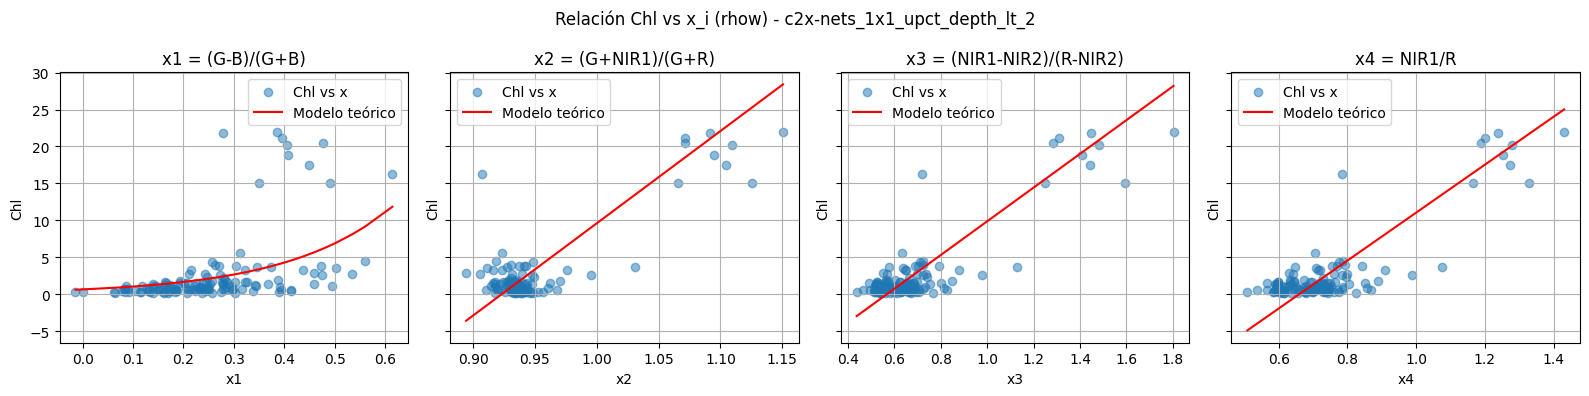

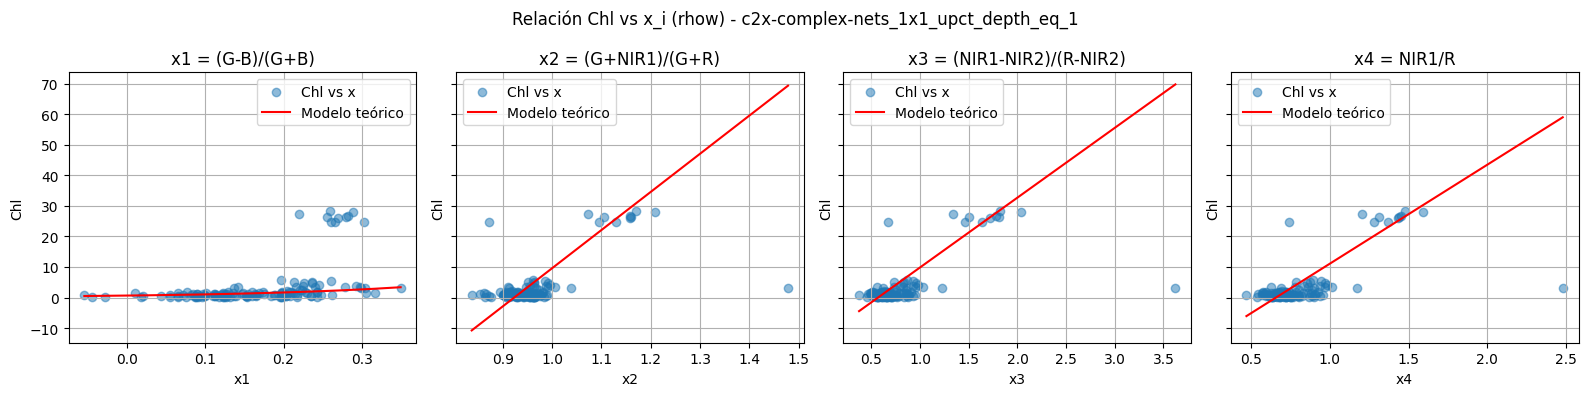

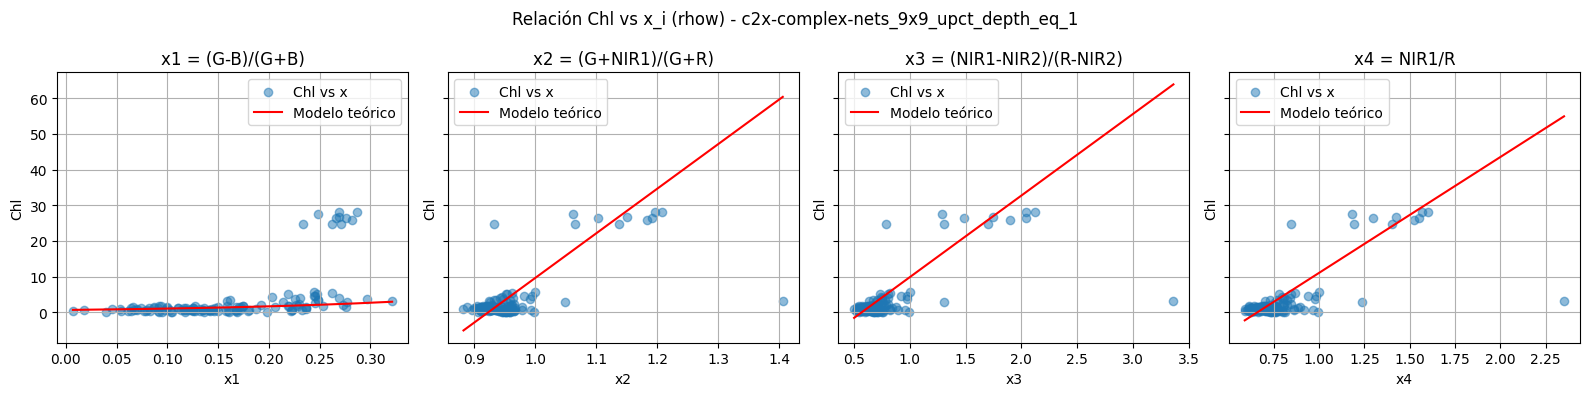

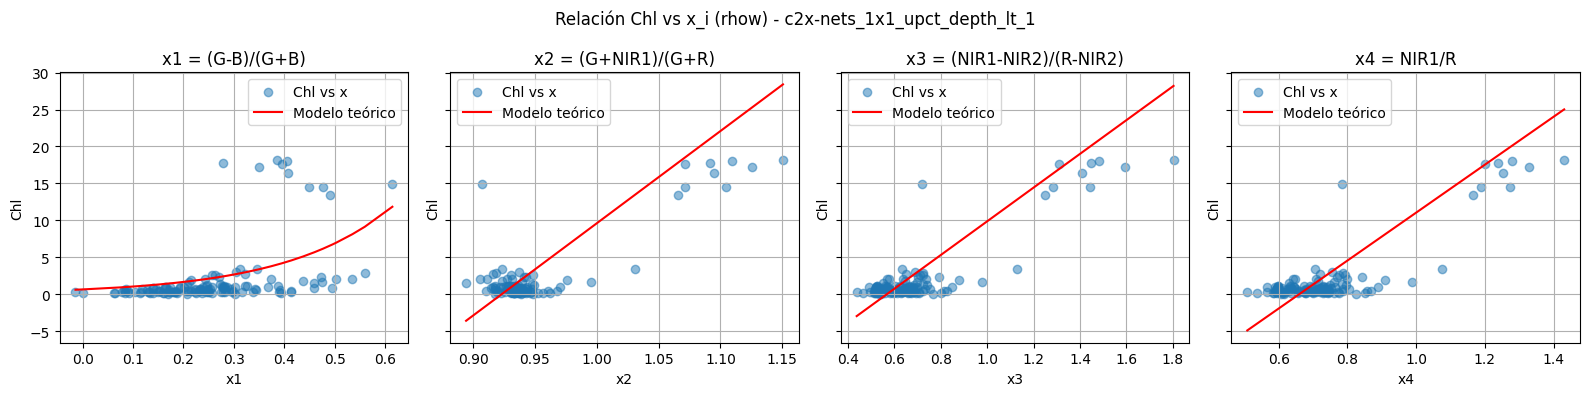

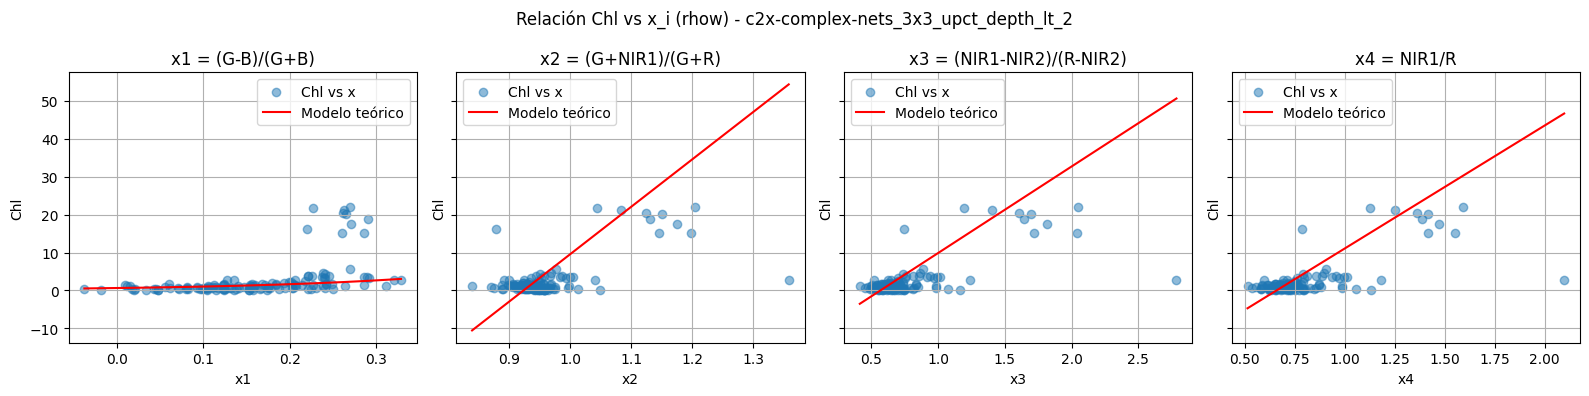

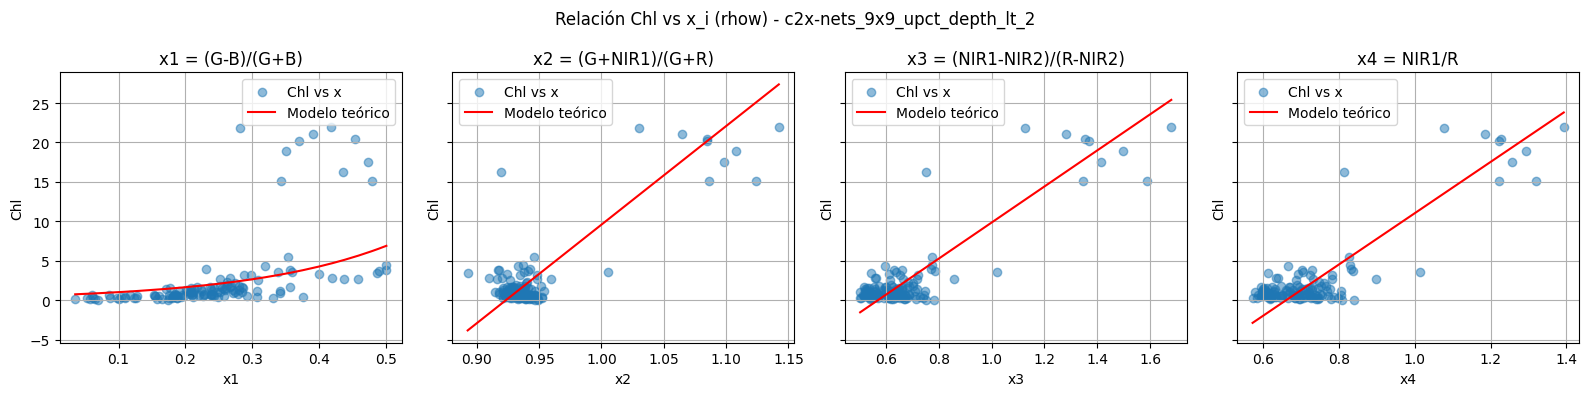

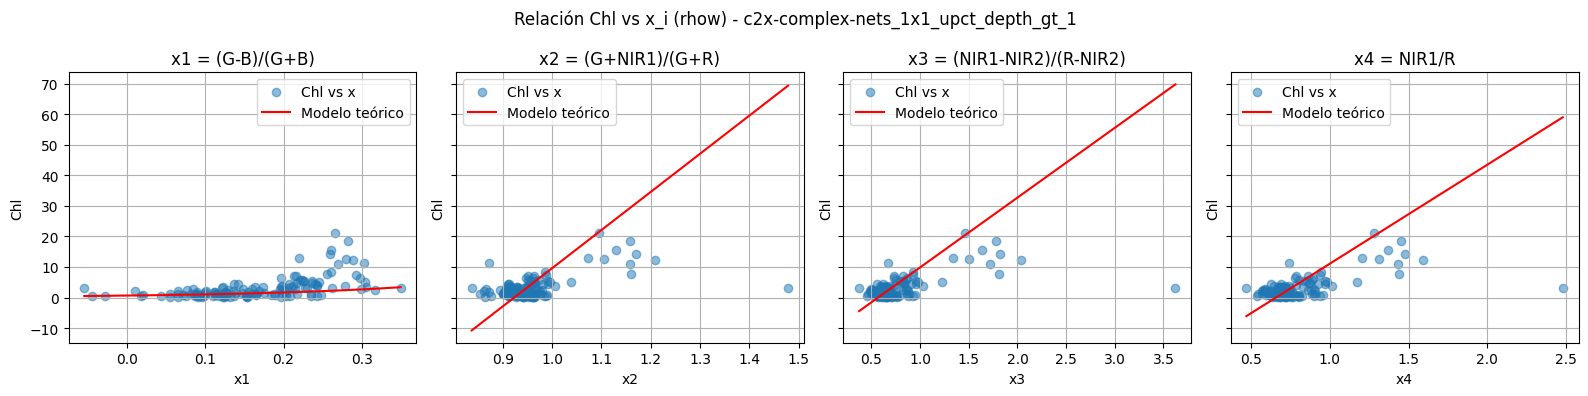

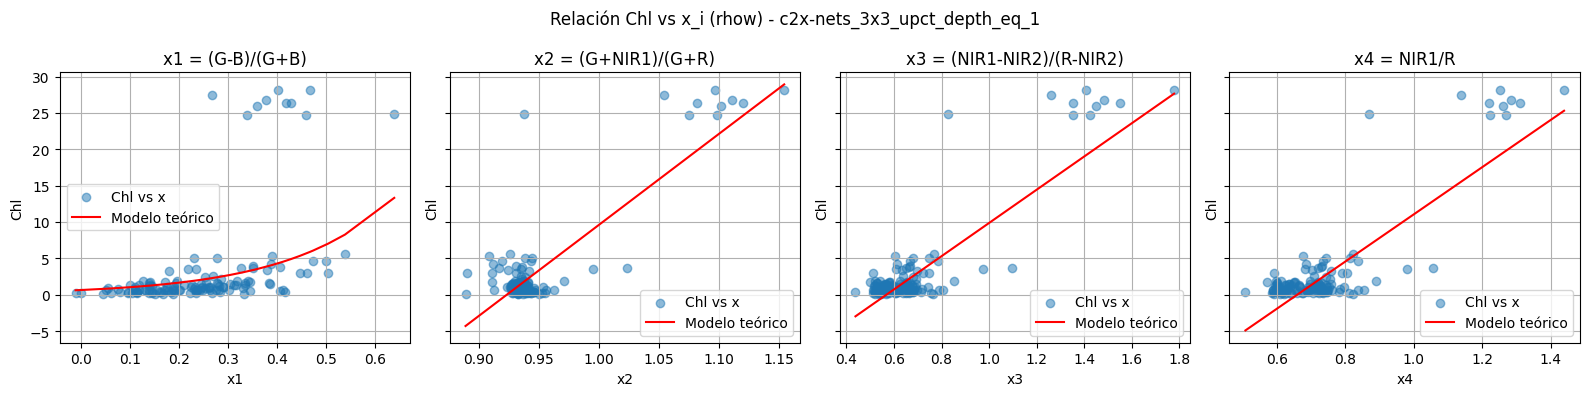

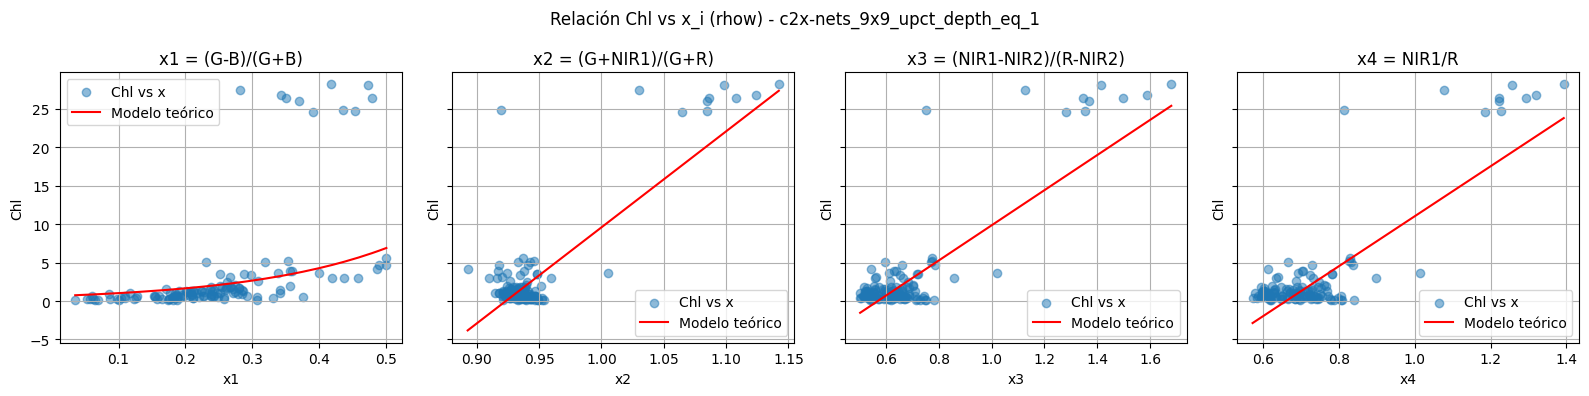

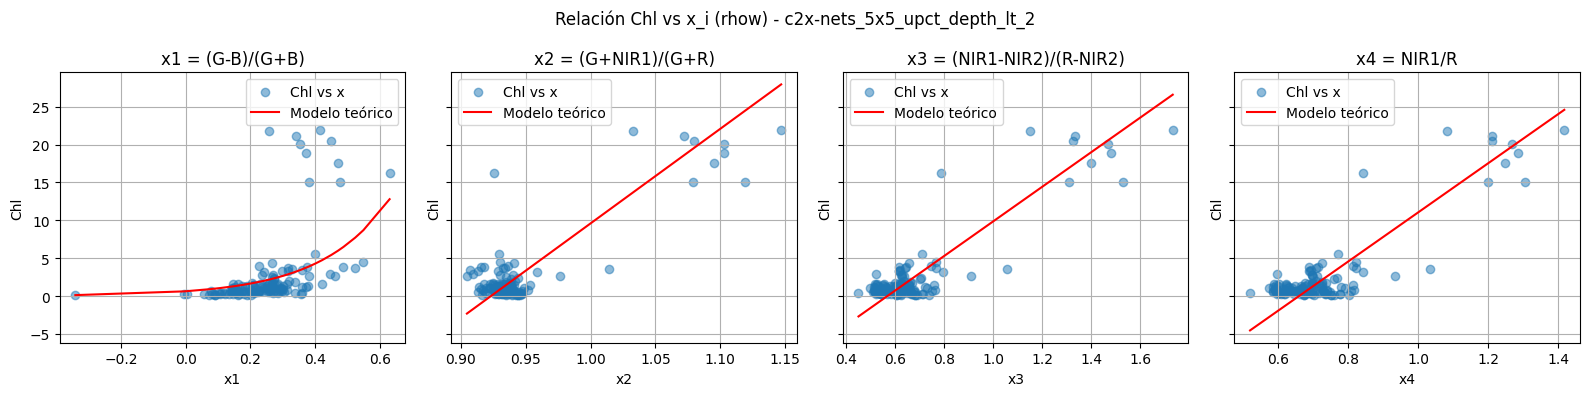

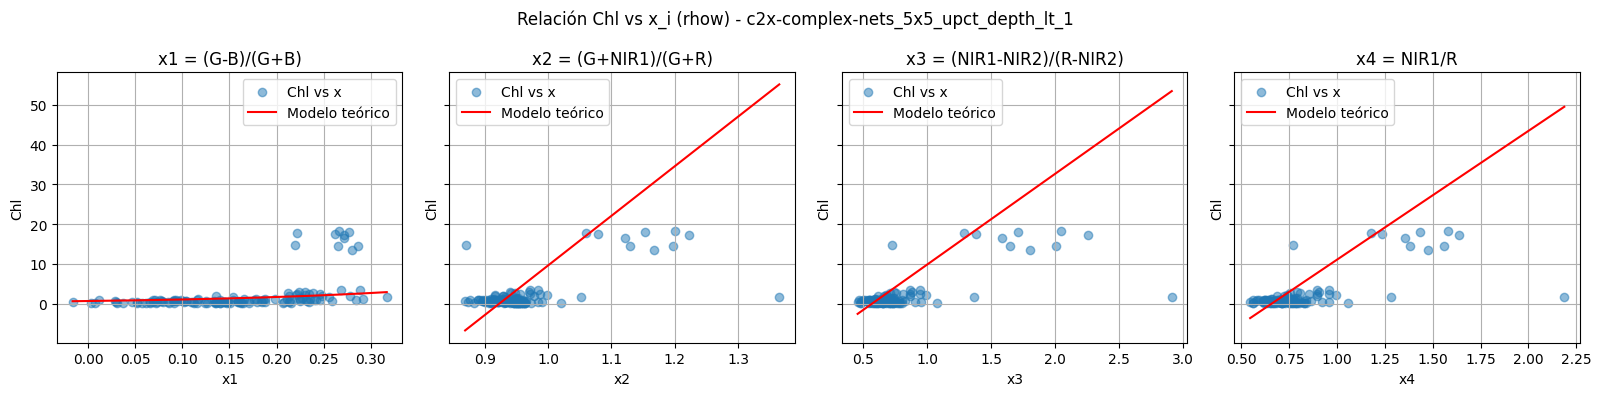

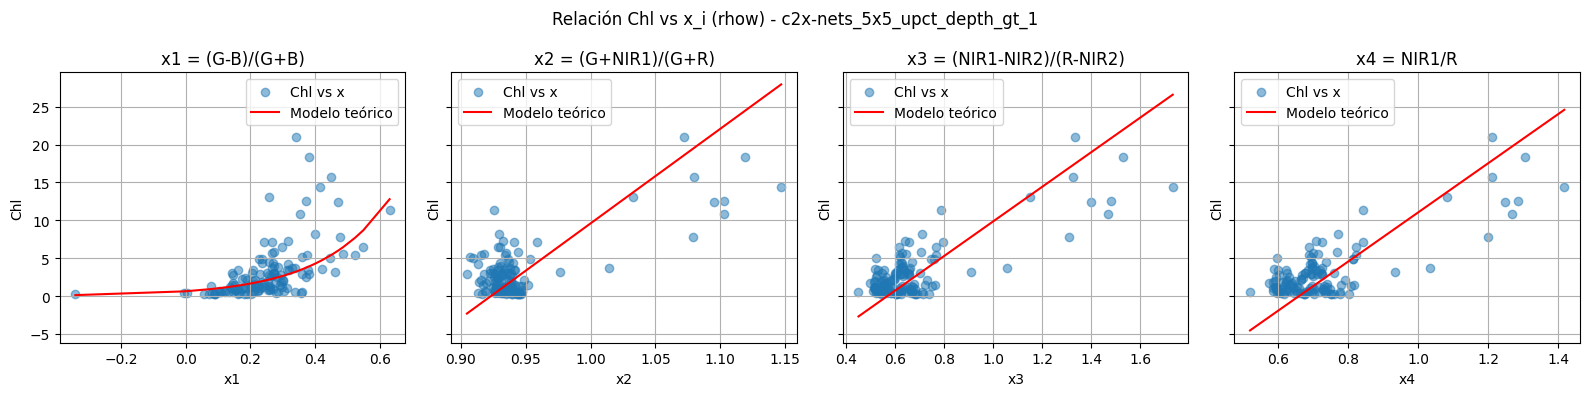

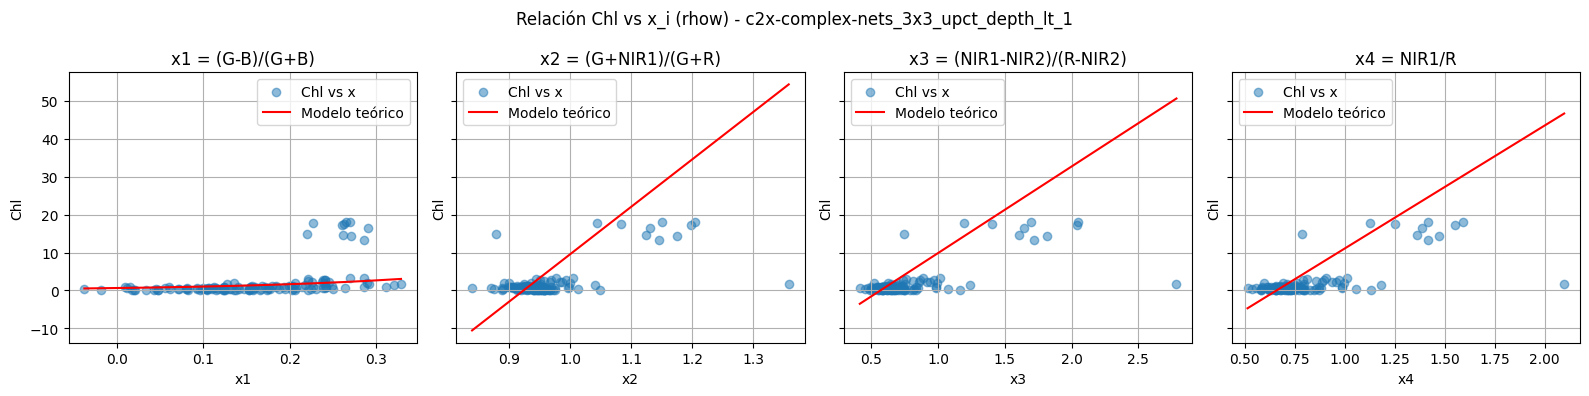

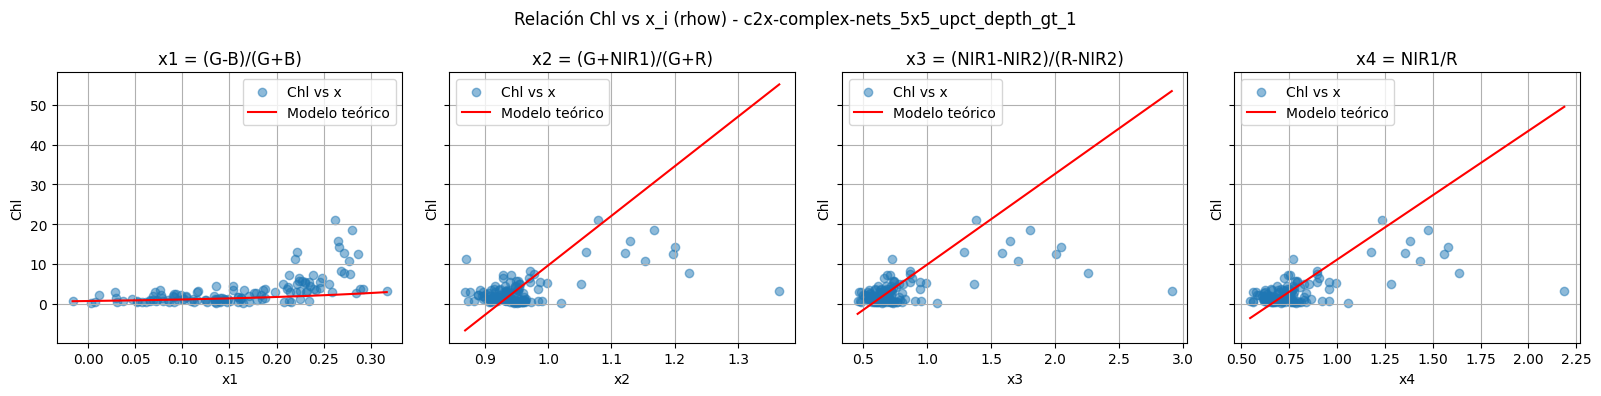

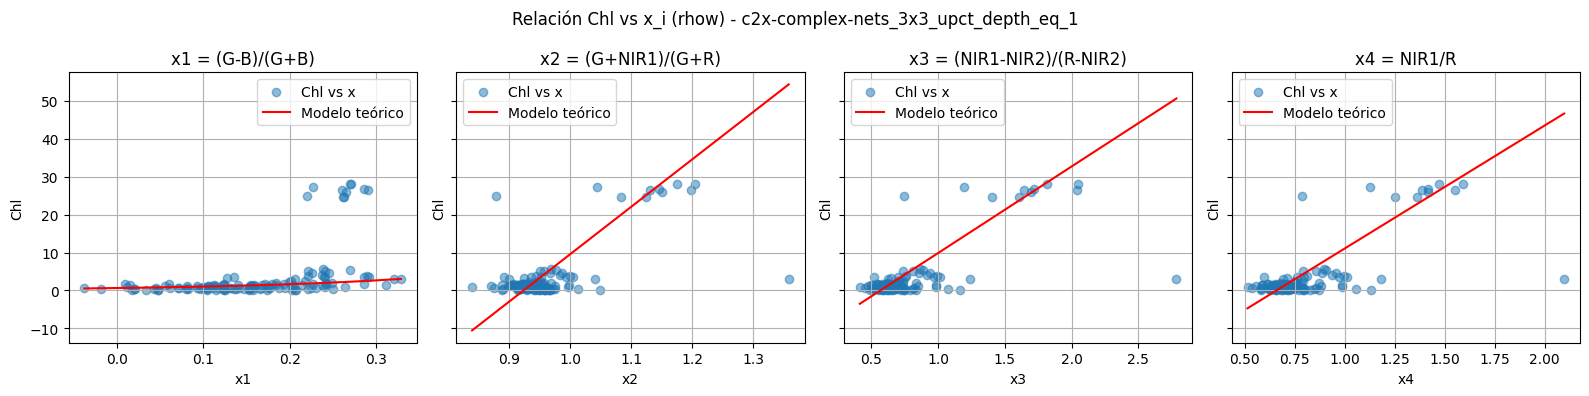

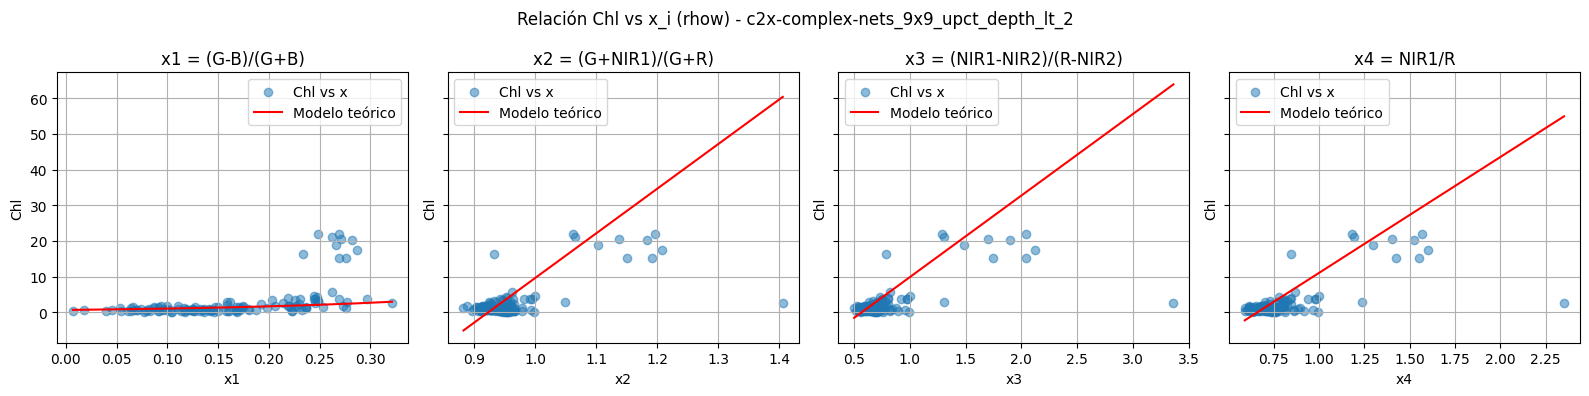

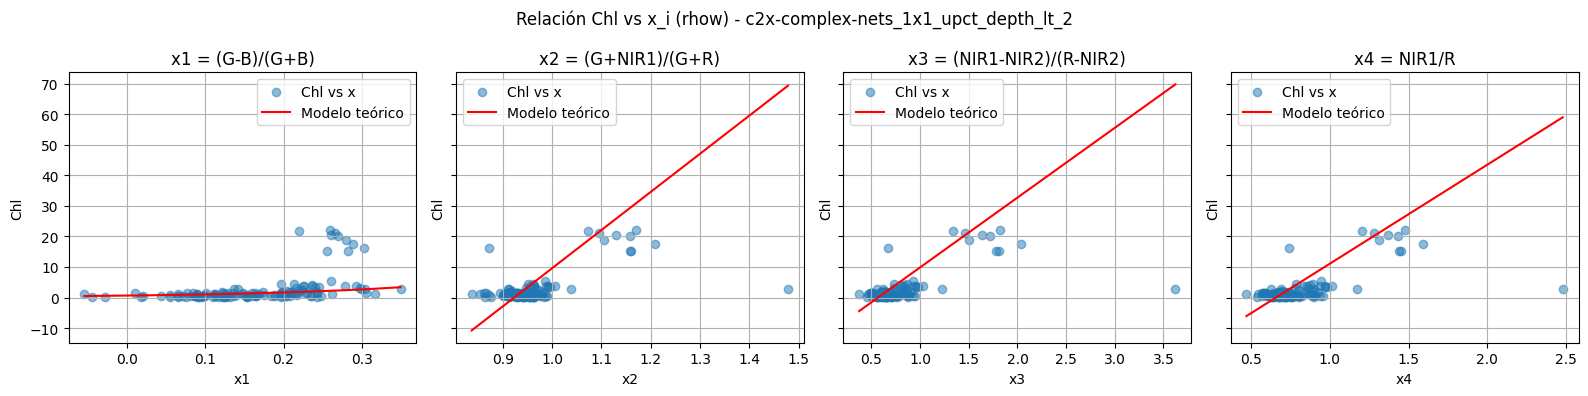

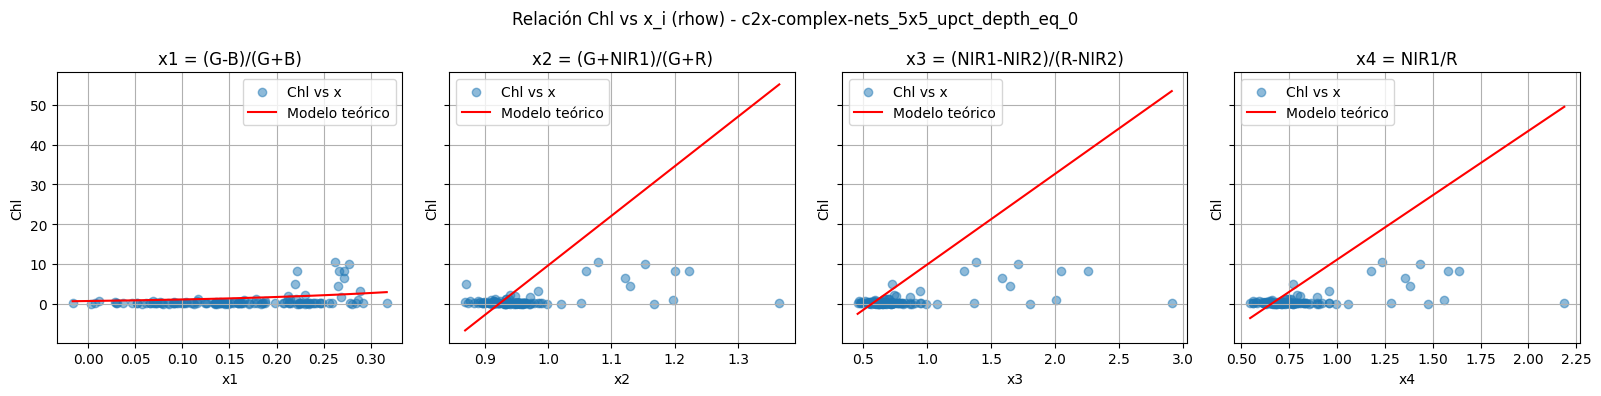

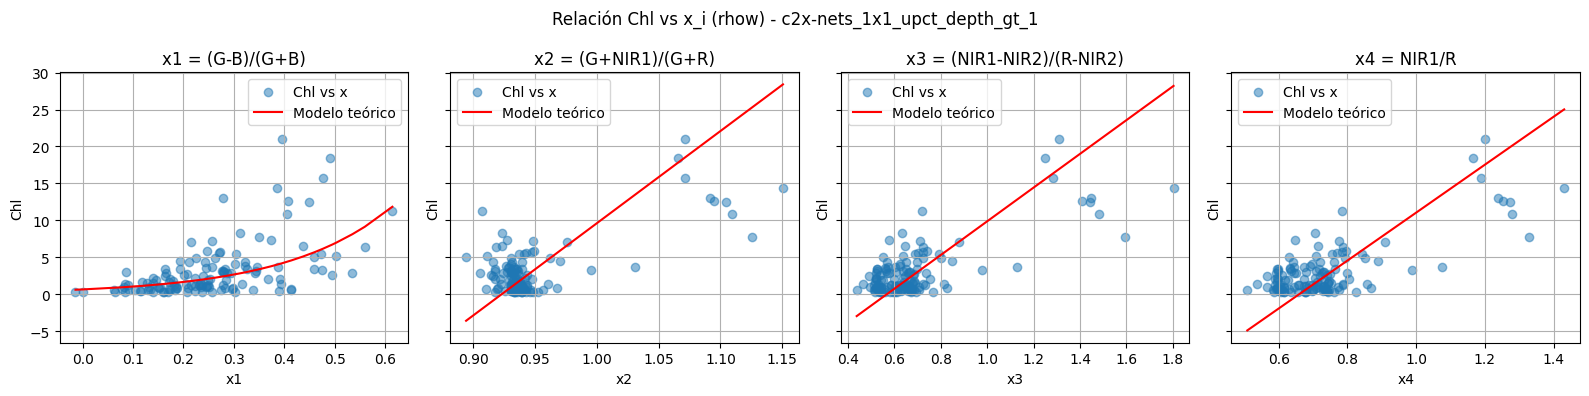

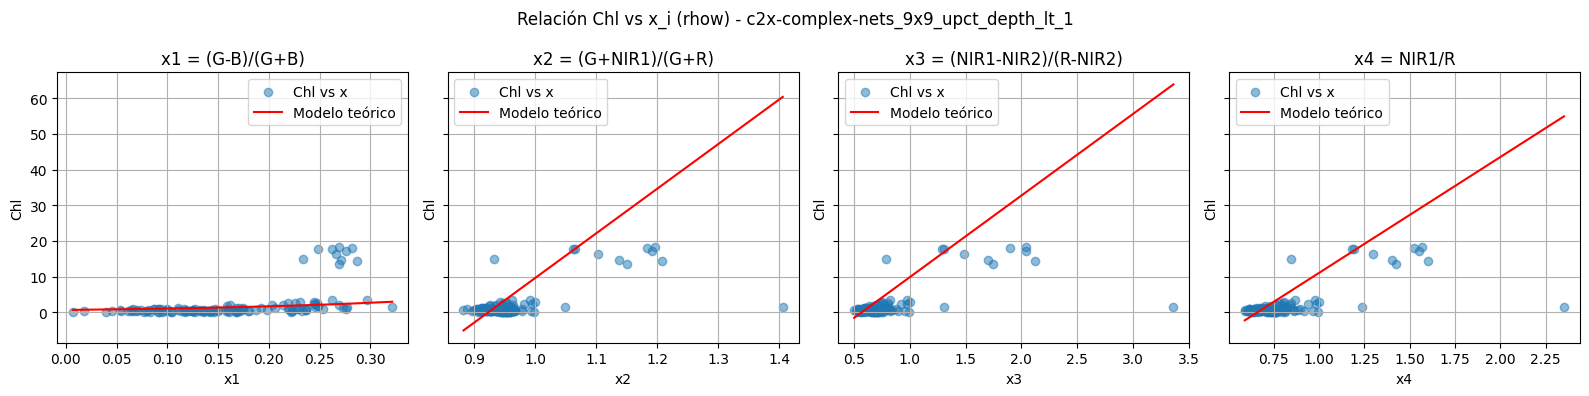

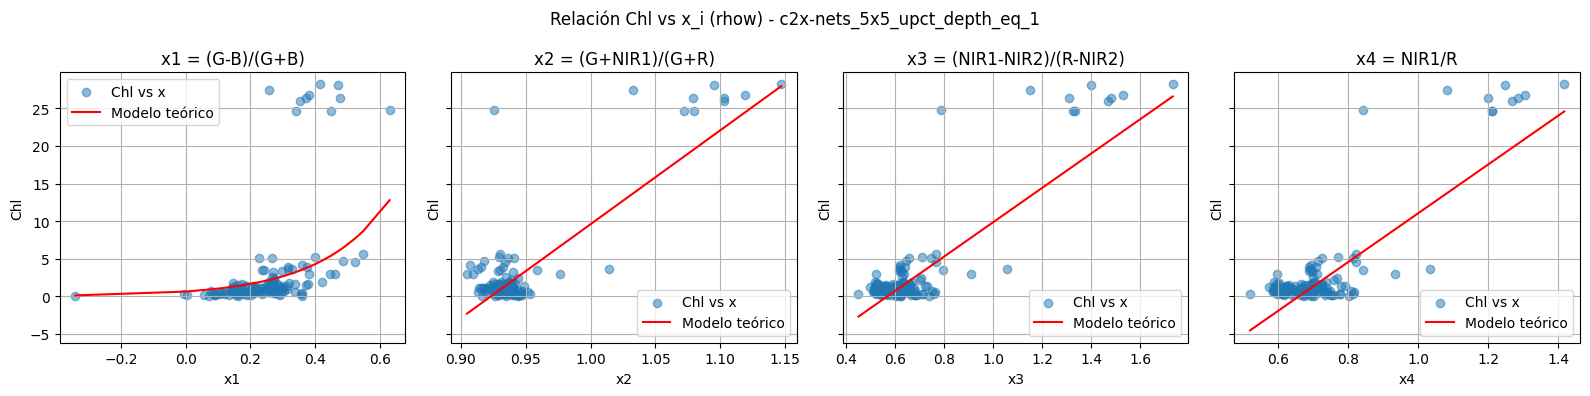

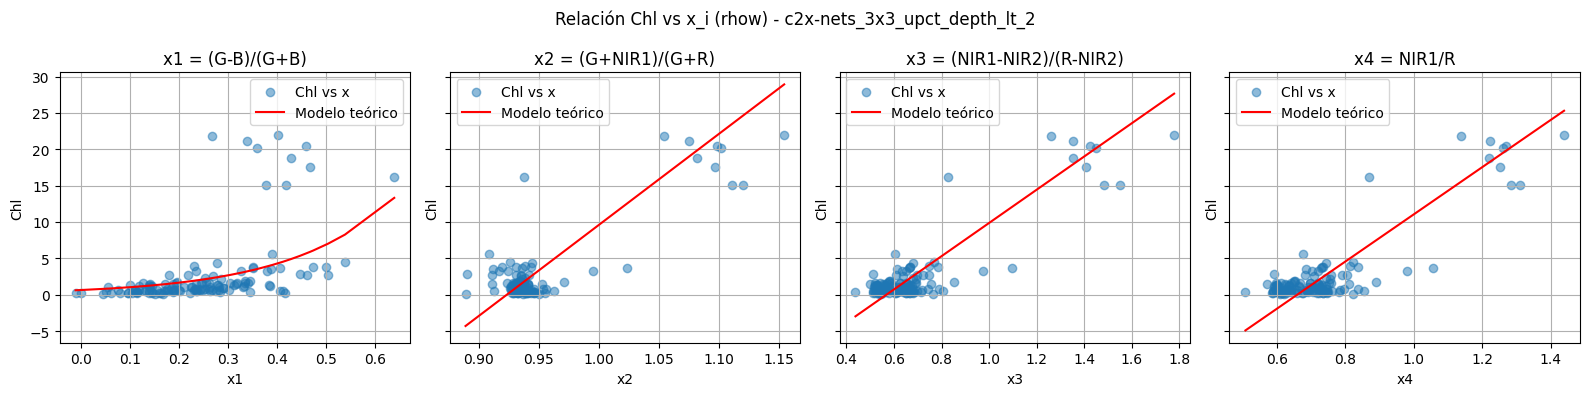

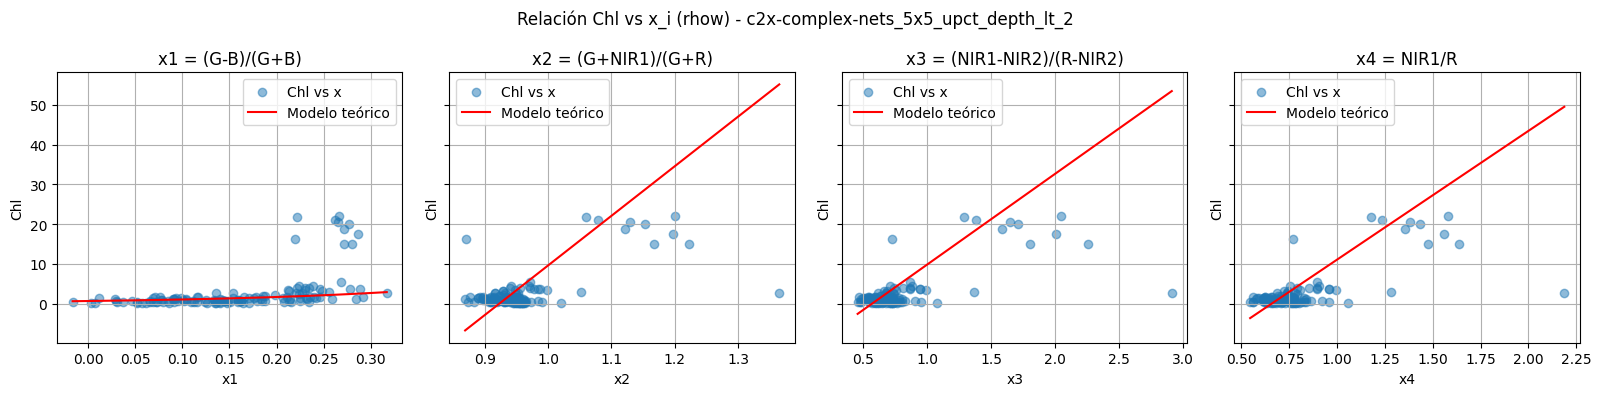

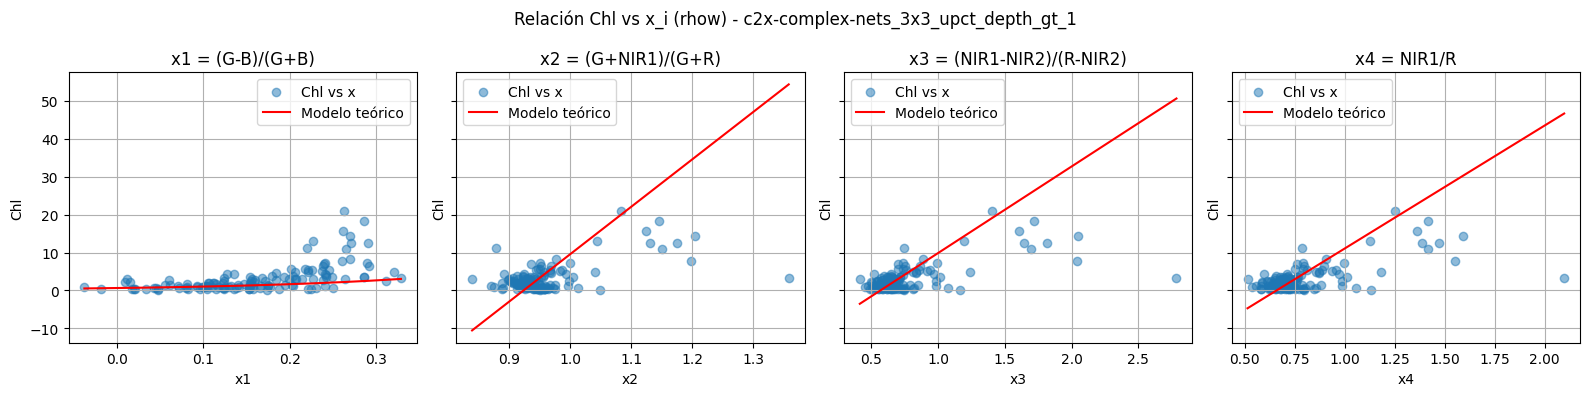

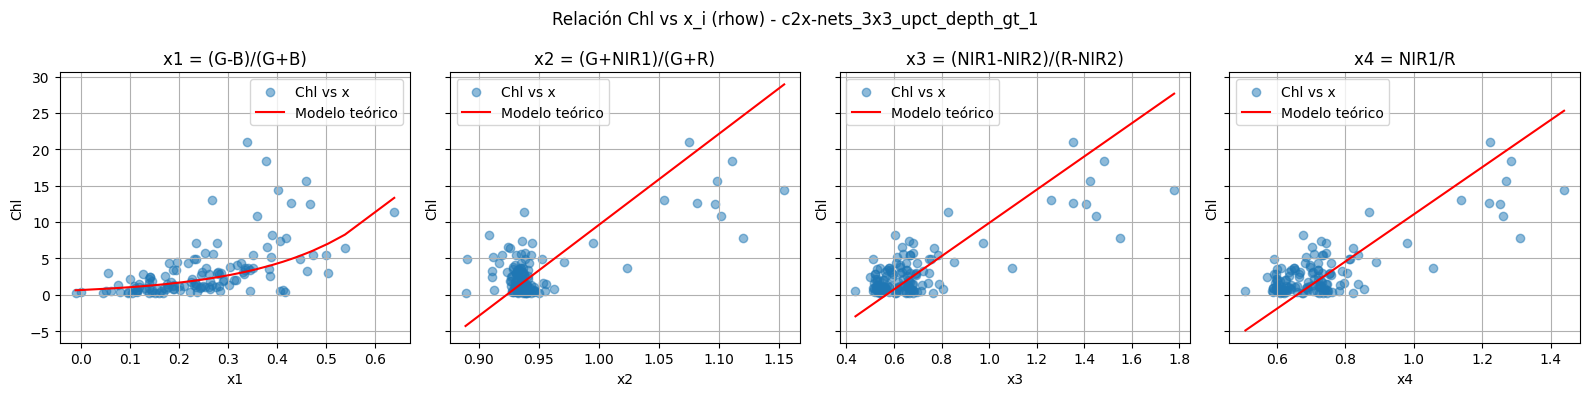

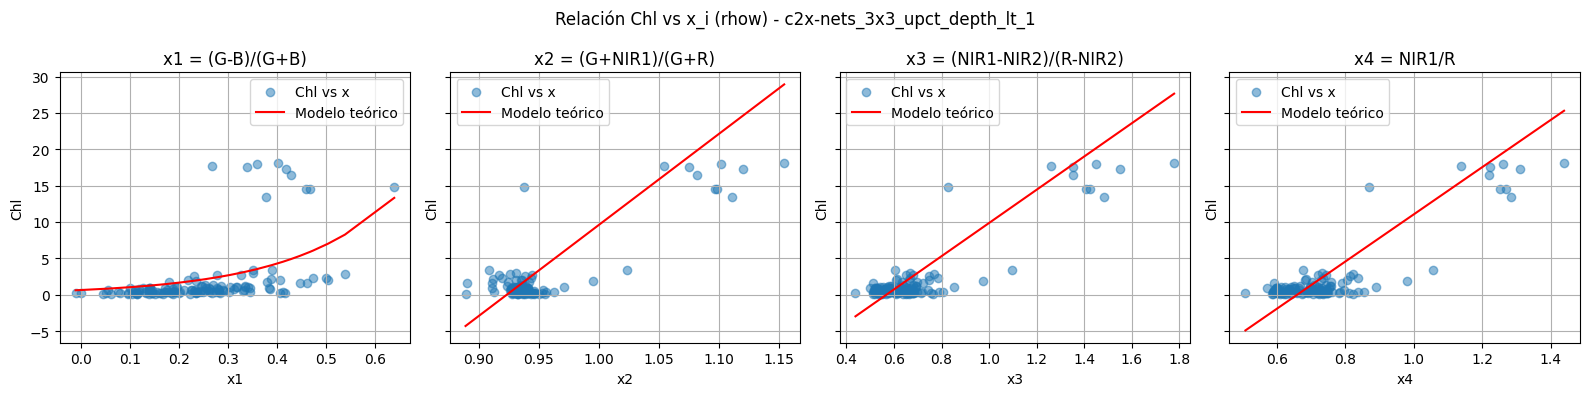

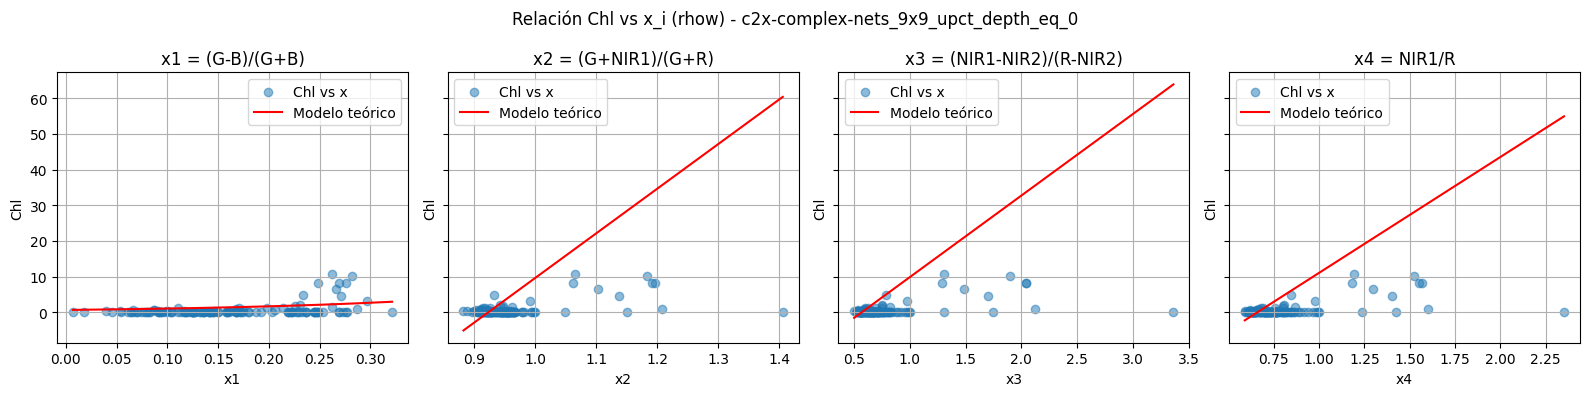

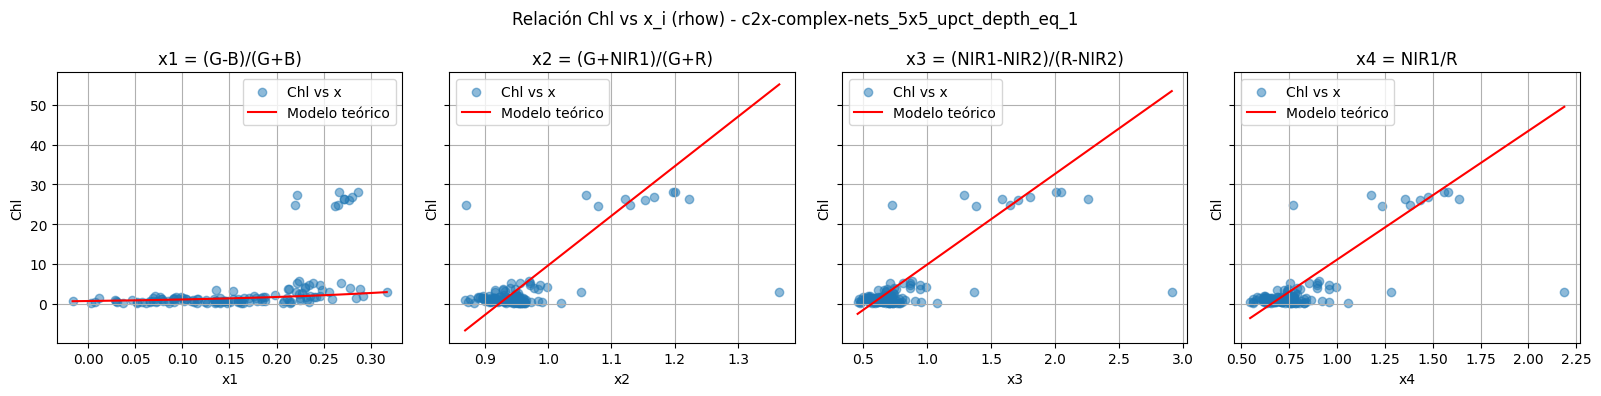

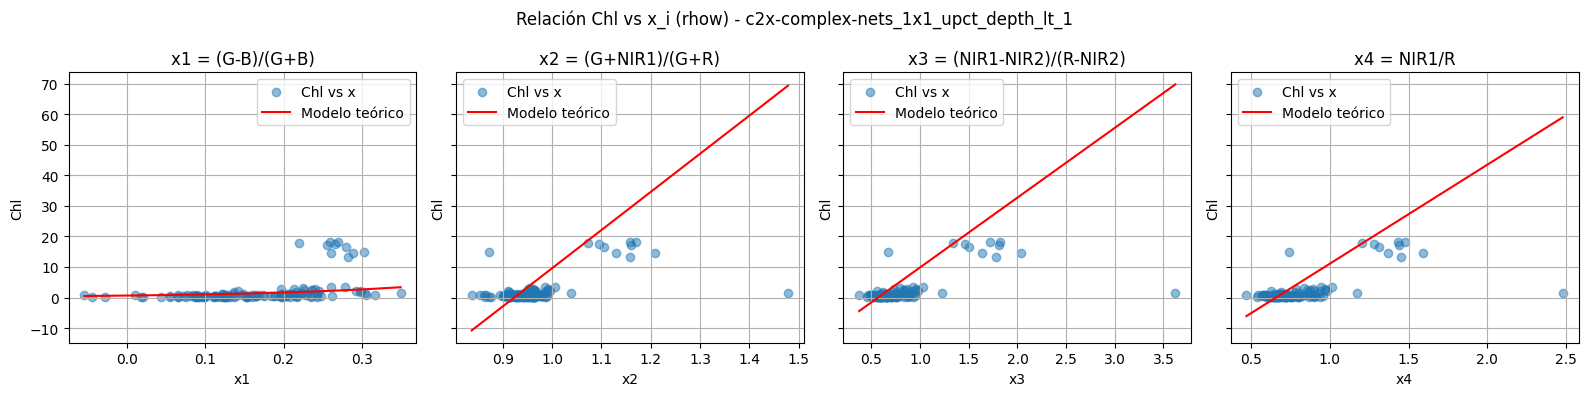

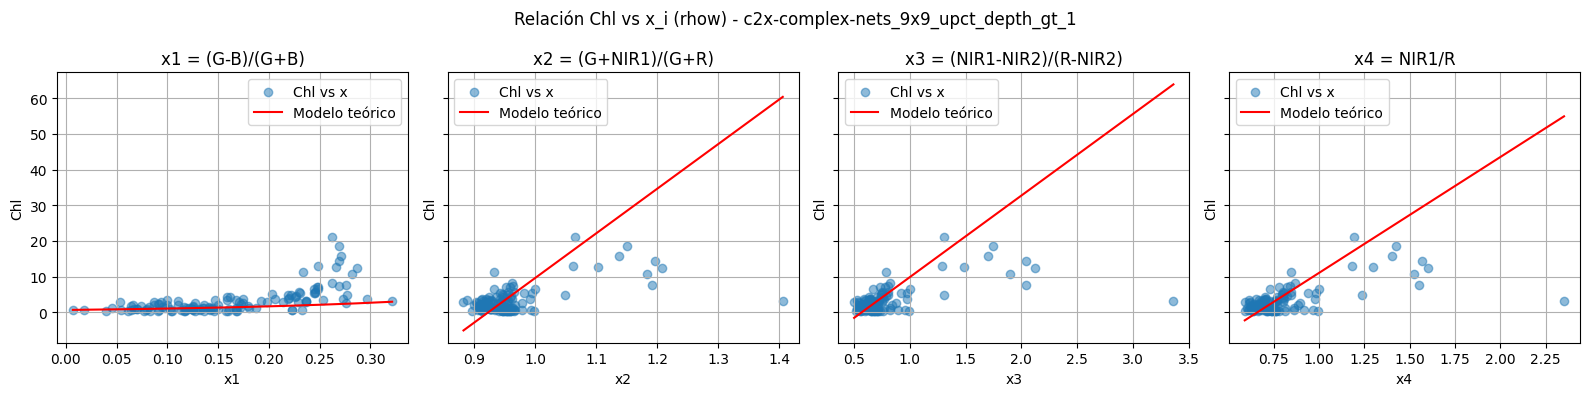

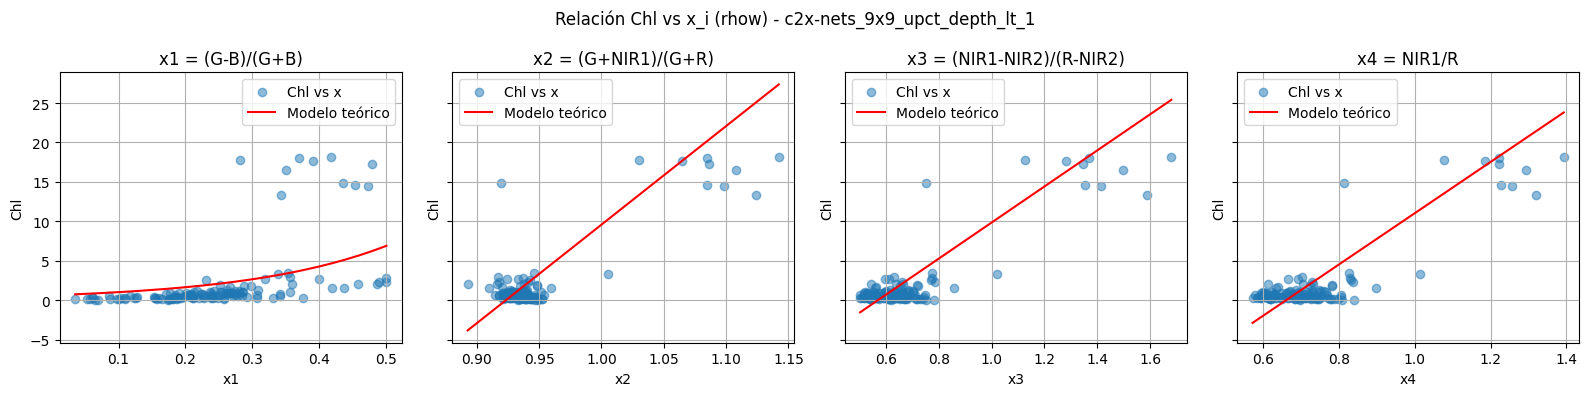

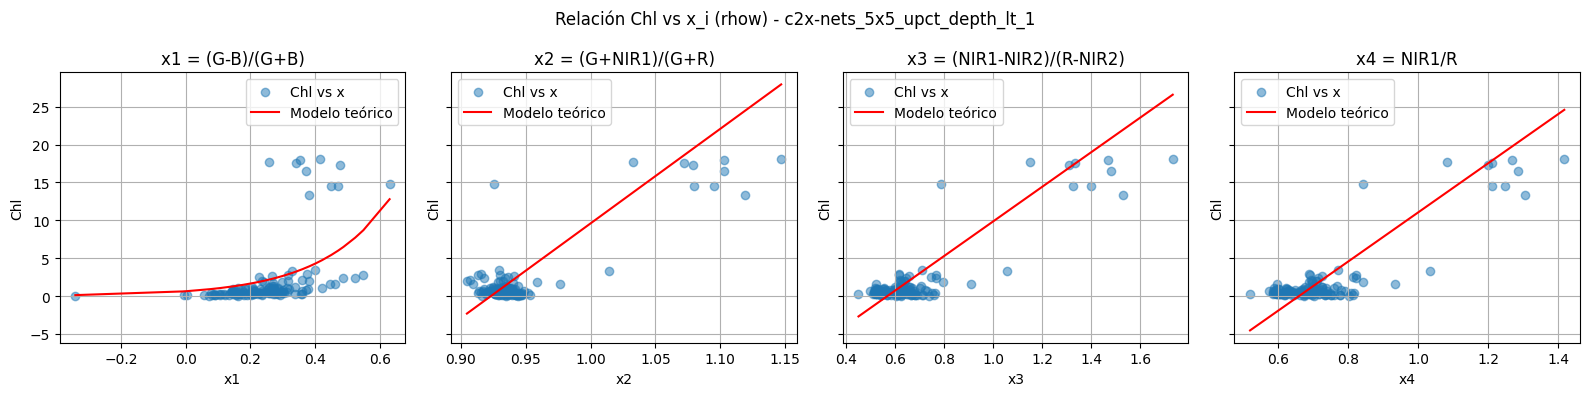

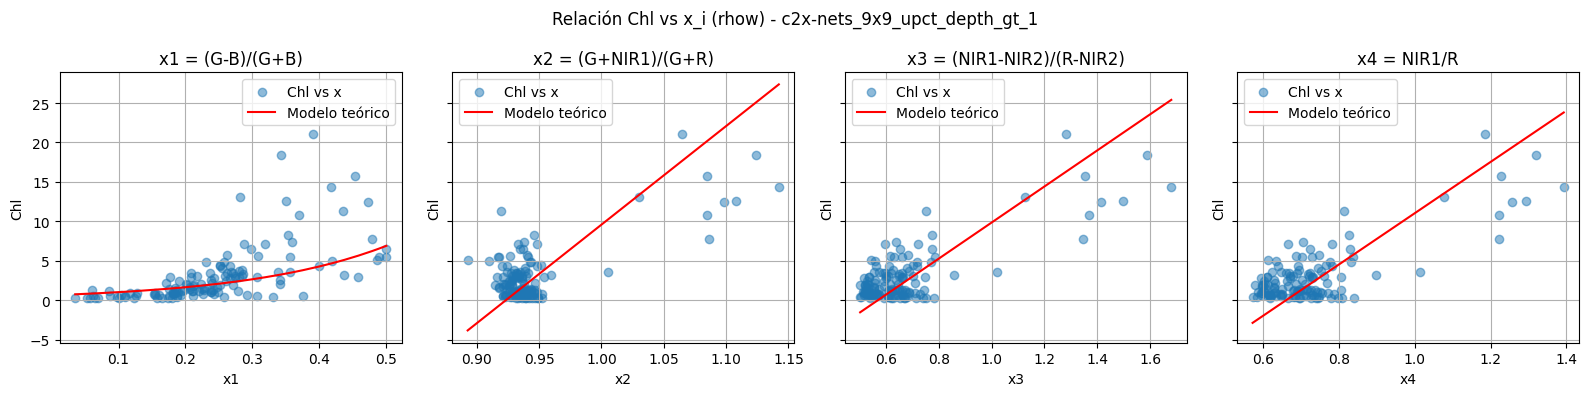

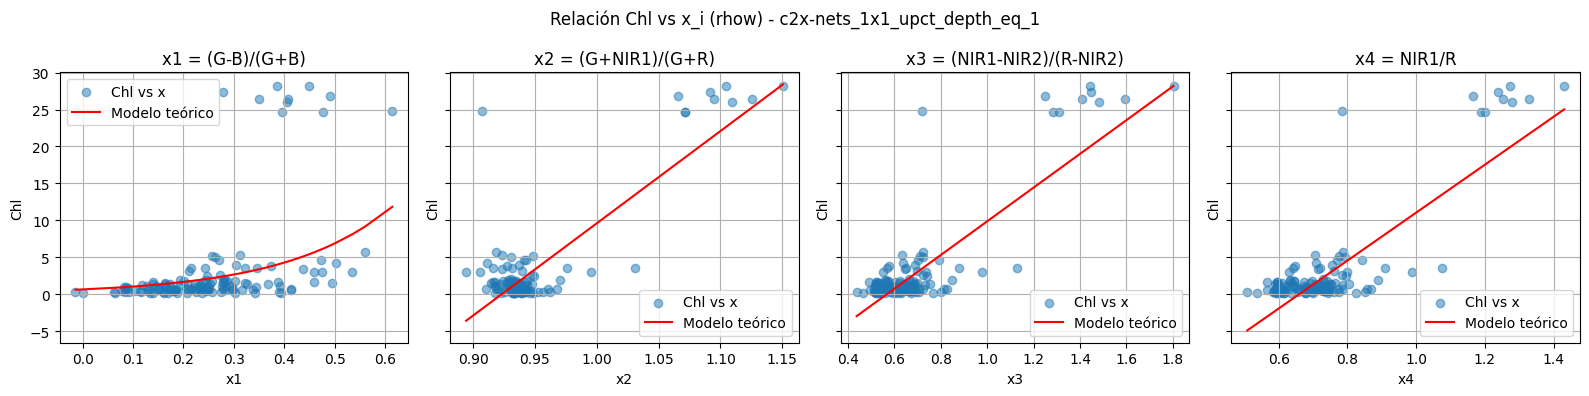

In [56]:
nombres_a_graficar = filtered_df[filtered_df.gt(0.0).any(axis=1)].index
for nombre_df in nombres_a_graficar:
    if nombre_df in dfs:
        df = dfs[nombre_df]
        columnas_necesarias = ["Chl", "rhow_B2", "rhow_B3", "rhow_B4", "rhow_B5", "rhow_B6"]
        if all(col in df.columns for col in columnas_necesarias):
            plot_chl_vs_x_rhow(df, nombre_df)

